### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data Dictionary: https://drive.google.com/file/d/1tMVsQwgH9LWFgL0za7qUAIdfYUKd6i29/view


**`Import data , cleaning , EDA`**

In [ ]:
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
product_category_name_translation = pd.read_csv('product_category_name_translation.csv')
print(customers.head())
print(geolocation.head())
print(order_items.head())
print(order_payments.head())
print(order_reviews.head())
print(orders.head())
print(products.head())
print(sellers.head())
print(product_category_name_translation.head())



                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                

In [ ]:
#check bảng customer
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
customers.customer_id.duplicated().sum()


np.int64(0)

In [ ]:
customers.customer_unique_id.duplicated().sum()

np.int64(3345)

In [ ]:
customers['customer_unique_id'].nunique()

96096

In [ ]:
customers['customer_city'].nunique()

4119

In [ ]:
#check bảng geolocation
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [ ]:
geolocation.geolocation_zip_code_prefix.duplicated().sum()

np.int64(981148)

In [ ]:
geo_clean = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

In [ ]:
#check bảng order_items
order_items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
order_items.order_id.duplicated().sum()

np.int64(13984)

In [ ]:
order_items.order_item_id.duplicated().sum()

np.int64(112629)

In [ ]:
order_items.product_id.duplicated().sum()

np.int64(79699)

In [ ]:

order_items.seller_id.duplicated().sum()

np.int64(109555)

In [ ]:
# định dạng lại ngày
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [ ]:
(order_items['price'] < 0).sum()

np.int64(0)

In [ ]:
(order_items['freight_value'] < 0).sum()

np.int64(0)

In [ ]:
#check bảng order_payments
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
order_payments['order_id'].duplicated().sum()

np.int64(4446)

In [ ]:
payment_clean = order_payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max'
}).reset_index()

In [ ]:
order_payments['payment_installments'].value_counts()

,count
payment_installments,
1,52546
2,12413
3,10461
4,7098
10,5328
5,5239
8,4268
6,3920
7,1626


In [ ]:
payment_clean['payment_value'].describe()

,payment_value
count,99440.000000
mean,160.990267
std,221.951257
min,0.000000
25%,62.010000
50%,105.290000
75%,176.970000
max,13664.080000


In [ ]:
#check bảng order_reviews
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
order_reviews['order_id'].duplicated().sum()

np.int64(551)

In [ ]:
order_reviews['review_score'].value_counts()

,count
review_score,
5,57328
4,19142
1,11424
3,8179
2,3151


In [ ]:
#định dạng datetime
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

In [ ]:
review_clean = order_reviews.groupby('order_id').agg({
    'review_score': 'mean',
    'review_id': 'count'
}).rename(columns={'review_id': 'num_reviews'}).reset_index()

In [ ]:
order_reviews.describe()

,review_score,review_creation_date,review_answer_timestamp
count,99224.000000,99224,99224
mean,4.086421,2018-01-12 20:49:23.948238336,2018-01-16 00:23:56.977938688
min,1.000000,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,4.000000,2017-09-23 00:00:00,2017-09-27 01:53:27.249999872
50%,5.000000,2018-02-02 00:00:00,2018-02-04 22:41:47.500000
75%,5.000000,2018-05-16 00:00:00,2018-05-20 12:11:21.500000
max,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,1.347579,NaN,NaN


In [ ]:
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date']).dt.date
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp']).dt.date

In [ ]:
#check bảng orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
#đinh dạng datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [ ]:
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [ ]:
#check bảng products
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
#xử lý null
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [ ]:
products = products.dropna(subset=[
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
])

In [ ]:
(products['product_weight_g'] <= 0).sum()

np.int64(4)

In [ ]:
products = products[products['product_weight_g'] > 0]

In [ ]:
products['product_category_name'].nunique()

74

In [ ]:
#check bảng sellers
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
sellers['seller_id'].duplicated().sum()

np.int64(0)

In [ ]:
#check bảng product_category_name
product_category_name_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


#### EDA

1. Nhóm khách hàng Best Customers có đặc điểm như thế nào? Số lượng?

In [ ]:
#1. Best Customers -> RFM analysis?
#R (Recency): mua gần đây không
#F (Frequency): mua nhiều không
#M (Monetary): chi tiêu nhiều không
df = orders.merge(order_items, on='order_id', how='left') \
           .merge(customers, on='customer_id', how='left')

In [ ]:
#Tính revenue per order
df['revenue'] = df['price'] + df['freight_value']

In [ ]:
#Aggregate về customer
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': 'max',
    'order_id': 'nunique',
    'revenue': 'sum'
}).reset_index()

In [ ]:
rfm.columns = ['customer_id', 'last_purchase', 'frequency', 'monetary', 'recency']

In [ ]:
#Tạo RFM
#1. Recency
import datetime as dt

snapshot_date = df['order_purchase_timestamp'].max()
rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

In [ ]:
#Chia nhóm
rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

In [ ]:
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])

In [ ]:
#Xd rank của rfm
rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)
print (rfm['RFM_score'])

0         9
1         6
2         4
3         4
4         7
         ..
96091    11
96092     9
96093     9
96094    12
96095     8
Name: RFM_score, Length: 96096, dtype: int64


In [ ]:
rfm['RFM_score'].value_counts().sort_index()


,count
RFM_score,
3,1010
4,3091
5,5962
6,9660
7,13364
8,15244
9,15113
10,12926
11,9402


In [ ]:
#Xác định ngưỡng đặt best_customer
best_customers = rfm[rfm['RFM_score'] >= 12]

In [ ]:
#Số lượng Best Customers
num_best = best_customers.shape[0]
total = rfm.shape[0]

print("Số lượng:", num_best)
print("Tỷ lệ:", num_best / total)

Số lượng: 10324
Tỷ lệ: 0.10743423243423243


In [ ]:
#Đặc điểm của best_customers
best_customers[['recency','frequency','monetary']].describe()

,recency,frequency,monetary
count,10324.00000,10324.000000,10324.000000
mean,164.62563,1.204572,334.621589
std,82.15620,0.513496,333.422210
min,0.00000,1.000000,86.730000
25%,95.00000,1.000000,166.347500
50%,151.00000,1.000000,235.795000
75%,221.00000,1.000000,363.702500
max,397.00000,17.000000,7274.880000


- Best Customers
Số lượng: 10,324 khách
Tỷ lệ: ~10.7%
=> Đây là nhóm top ~10% khách hàng
- Recency (mua gần đây không?)
Mean: 164 ngày (~5.5 tháng)
Median: 151 ngày
Min: 0 ngày
75%: 221 ngày
=> Không phải tất cả đều mua rất gần đây
Có khách đã 5–7 tháng chưa quay lại
- Frequency (tần suất mua)
Mean: 1.20
Median: 1
75%: 1
=> Hầu hết khách chỉ mua 1 lần
==> Best Cus: KHÔNG phải vì mua nhiều mà vì chi tiêu cao
- Monetary (chi tiêu)
Mean: 334; Median: 236; Max: 7274; Std: 333
=> Có sự phân hóa mạnh
Một số khách chi rất nhiều -> Nhóm này là high-value customers (giá trị cao)

==> Nhóm Best Customers (10324 chiếm khoảng 10.7% tổng số khách hàng.
Tuy nhiên, phần lớn khách trong nhóm này chỉ mua hàng một lần (frequency ≈ 1), nhưng có giá trị chi tiêu cao (monetary trung bình ~334).
Điều này cho thấy nhóm Best Customers chủ yếu là những khách hàng có giá trị đơn hàng lớn, thay vì mua hàng thường xuyên.
Ngoài ra, recency trung bình khoảng 5–6 tháng cho thấy một phần khách hàng trong nhóm này chưa quay lại gần đây, tiềm ẩn nguy cơ churn.
Như vậy, Best Customers không phải là khách trung thành, mà là khách có giá trị đơn hàng cao.

2. Đâu là các khách hàng rời bỏ? Số lượng?

In [ ]:
#Churn rate
#Theo RFM: Churn customers = Recency cao (lâu rồi chưa mua) + Frequency thấp (mua ít) + Monetary thấp (chi tiêu thấp)
churn_customers = rfm[
    (rfm['R_score'] <= 2) &
    (rfm['F_score'] <= 2) &
    (rfm['M_score'] <= 2)
]

In [ ]:
#Số lượng khách rời bỏ
num_churn = churn_customers.shape[0]
total = rfm.shape[0]

print("Số lượng churn:", num_churn)
print("Tỷ lệ:", num_churn / total)

Số lượng churn: 11474
Tỷ lệ: 0.1194014319014319


3. Nhóm khách hàng có khả năng Churned có đặc điểm như thế nào ?

In [ ]:
#Đặc điểm của churn customers
churn_customers[['recency','frequency','monetary']].describe()

,recency,frequency,monetary
count,11474.000000,11474.0,11474.000000
mean,218.244553,1.0,53.882634
std,96.475125,0.0,18.766410
min,36.000000,1.0,0.000000
25%,137.000000,1.0,38.935000
50%,220.000000,1.0,54.735000
75%,304.000000,1.0,69.040000
max,397.000000,1.0,86.720000


churn customers: Số lượng: 17,474 khách, chiếm tỷ lệ: ~11.94%
=> Chiếm gần 1/8 khách hàng đã rời bỏ hệ thống
- Frequency: Mean = 1.0; Median = 1;
=> Tất cả churn customers đều chỉ mua 1 lần duy nhất.
- Monetary: Mean: ~53.9; Median: ~54.7; 25%: ~38.9 => Chi tiêu rất thấp ->Đây là nhóm khách giá trị thấp rõ ràng.
- Recency: Mean: ~218 ngày (khoảng 7 tháng); Median: ~220 ngày; Min: 36 ngày; 25%: ~137 ngày.Phần lớn khách đã không quay lại trong 4–7 tháng

==> Nhóm khách hàng rời bỏ chiếm khoảng 11.94% tổng số khách hàng. Đáng chú ý, 100% khách hàng trong nhóm này chỉ thực hiện một lần mua duy nhất (frequency = 1), cho thấy họ không quay lại sau lần mua đầu tiên.
Ngoài ra, số tiền chi tiêu của nhóm này tương đối thấp (monetary trung bình ~54), và thời gian kể từ lần mua gần nhất khá dài (recency trung bình ~7 tháng).
Điều này cho thấy nhóm churn customers chủ yếu là những khách hàng mới, có giá trị thấp và không được chuyển đổi thành khách hàng trung thành.
Như vậy, vấn đề chính của doanh nghiệp không phải là mất khách hàng trung thành, mà là không giữ chân được khách hàng sau lần mua đầu tiên

4. Business Questions và thực hiện Exploratory Data

In [ ]:
#a.Tổng doanh thu & xu hướng theo thời gian

df = orders.merge(order_items, on='order_id', how='left')

df['revenue'] = df['price'] + df['freight_value']

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Tổng revenue
total_revenue = df['revenue'].sum()
print(total_revenue)

# Theo tháng
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df.groupby('month')['revenue'].sum().reset_index()


15843553.239999998


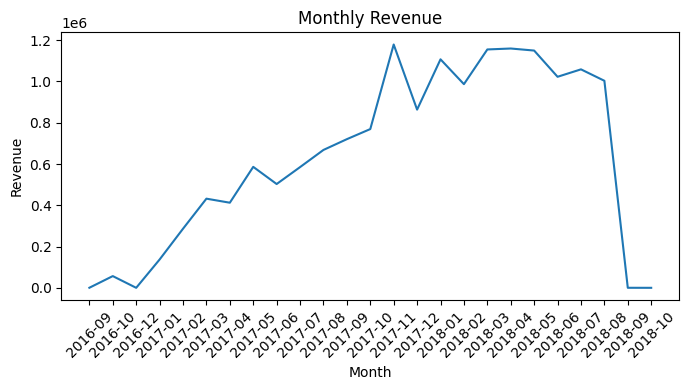

In [ ]:
#Vẽ biểu đồ xu hướng thời gian
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

plt.figure(figsize=(7,4))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

- Nhìn tổng thể:
2016 → đầu 2017: tăng trưởng nhanh
2017 → 2018: tiếp tục tăng + ổn định ở mức cao
Peak ~ cuối 2017 - đầu 2018
=> Doanh thu của Olist có xu hướng tăng trưởng mạnh theo thời gian, cho thấy nền tảng đang mở rộng và thu hút nhiều giao dịch hơn.
- Giai đoạn tăng trưởng mạnh
Từ: 2017-01 → 2017-10
Doanh thu:tăng từ ~100k → ~800k+
=> Giai đoạn 2017 là thời kỳ tăng trưởng nhanh, có thể do mở rộng seller hoặc marketing hiệu quả.
- Đỉnh doanh thu:
+ 2017-11 (~1.2M)
+ 2018-03 ~ 2018-04 (~1.15M)
=> Doanh thu đạt đỉnh vào cuối năm 2017 và đầu năm 2018, có thể liên quan đến mùa mua sắm hoặc chiến dịch lớn.
- 2018-09 → 2018-10: Doanh thu rơi về 0 có thể do dataset chưa thu thập đủ dữ liệu

==> Doanh thu của Olist có xu hướng tăng trưởng mạnh từ năm 2016 đến 2018, đặc biệt tăng nhanh trong năm 2017.
Doanh thu đạt đỉnh vào cuối năm 2017 và đầu năm 2018, cho thấy khả năng có ảnh hưởng từ các mùa mua sắm cao điểm.
Tuy nhiên, doanh thu có sự biến động giữa các tháng, phản ánh yếu tố mùa vụ trong hành vi tiêu dùng.
Ngoài ra, dữ liệu cho thấy doanh thu giảm về 0 trong các tháng cuối năm 2018, nhiều khả năng do dữ liệu chưa đầy đủ.

In [ ]:
#b. Có bao nhiêu đơn đặt hàng được đặt trên Olist và số lượng các đơn hàng thay đổi như thế nào theo tháng hoặc mùa?
# Số đơn hàng
total_orders = orders['order_id'].nunique()

# Theo tháng
orders['month'] = pd.to_datetime(orders['order_purchase_timestamp']).dt.to_period('M')

monthly_orders = orders.groupby('month')['order_id'].nunique().reset_index()
print(monthly_orders)
print(total_orders)

      month  order_id
0   2016-09         4
1   2016-10       324
2   2016-12         1
3   2017-01       800
4   2017-02      1780
5   2017-03      2682
6   2017-04      2404
7   2017-05      3700
8   2017-06      3245
9   2017-07      4026
10  2017-08      4331
11  2017-09      4285
12  2017-10      4631
13  2017-11      7544
14  2017-12      5673
15  2018-01      7269
16  2018-02      6728
17  2018-03      7211
18  2018-04      6939
19  2018-05      6873
20  2018-06      6167
21  2018-07      6292
22  2018-08      6512
23  2018-09        16
24  2018-10         4
99441


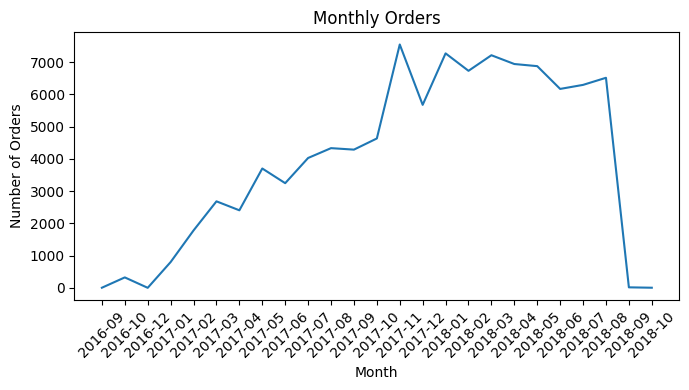

In [ ]:
# Vẽ biểu đồ xu hướng
monthly_orders['month'] = monthly_orders['month'].astype(str)

plt.figure(figsize=(7,4))
plt.plot(monthly_orders['month'], monthly_orders['order_id'])
plt.xticks(rotation=45)
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

- Xu hướng tổng thể số đơn hàng:
2016 → 2017: tăng mạnh
2017 → 2018: duy trì mức cao
=> Số lượng đơn hàng trên Olist tăng trưởng mạnh theo thời gian, cho thấy DN đang mở rộng và thu hút nhiều người dùng hơn.
- Giai đoạn tăng trưởng nhanh
+Từ đầu 2017 → cuối 2017
+ Số đơn tăng từ ~500 → ~7500
=> Năm 2017 là giai đoạn tăng trưởng bùng nổ về số lượng đơn hàng, phản ánh sự mở rộng nhanh chóng của DN.
- đỉnh đơn hàng cao nhất khoảng 2017-11 (~7500 đơn)
=> Số đơn hàng đạt đỉnh vào tháng 11/2017, có thể liên quan đến các dịp mua sắm lớn như Black Friday.
- Giai đoạn ổn định: năm 2018: dao động quanh ~6500–7200 đơn
=> Sau giai đoạn tăng trưởng, số lượng đơn hàng ổn định ở mức cao trong năm 2018, cho thấy DN đã đạt trạng thái phát triển ổn định.
- 2018-09 → 2018-10: drop về 0 có thể do data chưa thu thập đầy đủ.

==> Số lượng đơn hàng trên Olist tăng trưởng mạnh từ năm 2016 đến 2017, đặc biệt bùng nổ trong năm 2017.
Đỉnh điểm số đơn hàng đạt vào tháng 11/2017, có thể liên quan đến các sự kiện mua sắm lớn như Black Friday.
Trong năm 2018, số lượng đơn hàng duy trì ổn định ở mức cao, cho thấy DN đã đạt được sự phát triển bền vững.
Ngoài ra, dữ liệu cho thấy sự sụt giảm về 0 trong các tháng cuối năm 2018, nhiều khả năng do dữ liệu chưa đầy đủ

In [ ]:
#c. Các danh mục sản phẩm phổ biến nhất trên Olist là gì và doanh số bán hàng của chúng khác nhau như thế nào?


In [ ]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'month',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'revenue',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [ ]:
df = orders.merge(order_items, on='order_id', how='left')

df['revenue'] = df['price'] + df['freight_value']

df = df.merge(products, on='product_id', how='left')
print(df.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15

In [ ]:
#Category phổ biến nhất
category_revenue = df.groupby('product_category_name')['revenue'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)
print(category_revenue)

product_category_name
beleza_saude              1441248.07
relogios_presentes        1305541.61
cama_mesa_banho           1240555.30
esporte_lazer             1156656.48
informatica_acessorios    1059272.40
moveis_decoracao           902511.79
utilidades_domesticas      778397.77
cool_stuff                 719329.95
automotivo                 685384.32
ferramentas_jardim         584219.21
Name: revenue, dtype: float64


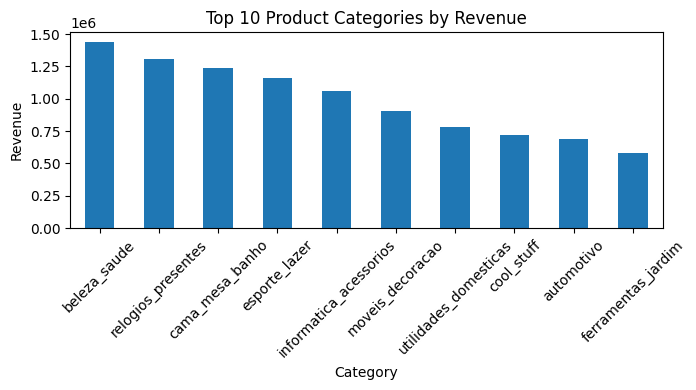

In [ ]:
# Vẽ biểu đồ Top Category theo doanh thu
top_categories = category_revenue.head(10)

plt.figure(figsize=(7,4))
top_categories.plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

- Top category theo doanh thu: Top 3:
1. beleza_saude (Beauty & Health) ~1.45M
2. relogios_presentes (Watches & Gifts) ~1.3M
3. cama_mesa_banho (Bed, Bath & Table) ~1.25M
=> Các danh mục liên quan đến chăm sóc cá nhân, quà tặng và gia dụng chiếm doanh thu cao nhất trên nền tảng.
- Nhóm category chính có thể chia thành 3 nhóm:
1. Nhóm Lifestyle / tiêu dùng cá nhân: beleza_saude; relogios_presentes; cama_mesa_banho
=> Đây là nhóm nhu cầu thiết yếu và tiêu dùng thường xuyên
2. Nhóm giải trí / thể thao: esporte_lazer
3. Nhóm công nghệ & nhà cửa: informatica_acessorios; moveis_decoracao;
utilidades_domesticas.
- Sự chênh lệch doanh thu theo biểu đồ cho thấy
Doanh thu giữa các danh mục có sự chênh lệch đáng kể (~2.5 lần giữa cao nhất 1,45m, ở giữa 0,6m), cho thấy thị trường tập trung vào một số ngành hàng chủ lực
- Top 10 Category đã chiếm phần lớn doanh thu.
- Các danh mục có doanh thu cao chủ yếu là sản phẩm tiêu dùng phổ biến, cho thấy hành vi mua hàng của khách hàng tập trung vào các nhu cầu thiết yếu và quà tặng
==> Các danh mục sản phẩm phổ biến nhất trên Olist bao gồm Beauty & Health, Watches & Gifts, và Bed, Bath & Table.
Những danh mục này đóng góp doanh thu cao nhất, phản ánh nhu cầu lớn đối với các sản phẩm tiêu dùng cá nhân và gia dụng.
Ngoài ra, doanh thu giữa các danh mục có sự chênh lệch đáng kể, cho thấy thị trường tập trung vào một số ngành hàng chủ lực, trong khi các danh mục khác đóng góp ít hơn.



In [ ]:
#d. Giá trị Average Order Value (AOV) trên Olist là bao nhiêu và giá trị này thay đổi như thế nào theo Product Category hoặc Payment Method?
#AOV tổng
order_value = df.groupby('order_id')['revenue'].sum().reset_index()

AOV = order_value['revenue'].mean()
print(AOV)

159.32616566607336


In [ ]:
# dịch category name sang tieng anh
df = df.merge(
    product_category_name_translation,
    on='product_category_name',
    how='left'
)

In [ ]:
#AOV theo category
df_order_cat = df.groupby(['order_id','product_category_name_english'])['revenue'].sum().reset_index()

AOV_category = df_order_cat.groupby('product_category_name_english')['revenue'].mean()
print(AOV_category)

product_category_name_english
agro_industry_and_commerce    430.626758
air_conditioning              244.166759
art                           139.840644
arts_and_craftmanship          94.962609
audio                         161.139829
                                 ...    
stationery                    120.182479
tablets_printing_image        110.817848
telephony                      94.042229
toys                          144.460255
watches_gifts                 232.137555
Name: revenue, Length: 71, dtype: float64


In [ ]:
df_order_cat = df.groupby(['order_id','product_category_name_english'])['revenue'] \
    .sum() \
    .reset_index()

AOV_category = df_order_cat.groupby('product_category_name_english')['revenue'] \
    .mean() \
    .sort_values(ascending=False)

In [ ]:
top_aov_cat = AOV_category.head(10)

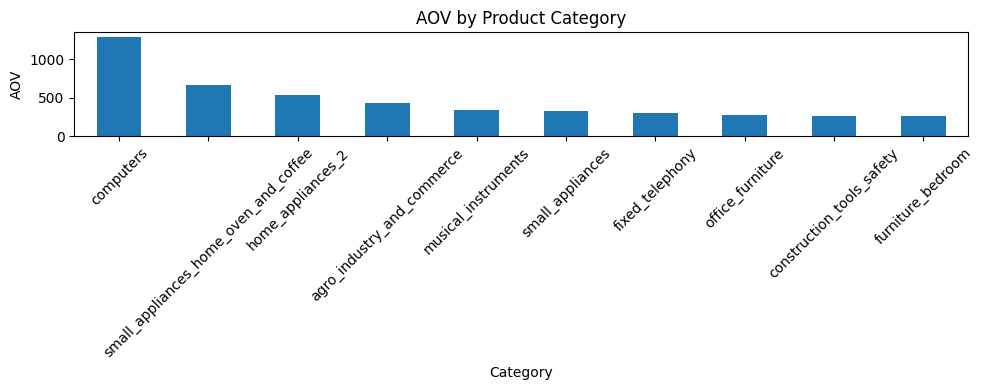

In [ ]:
#top_aov_cat = AOV_category.head(10)

plt.figure(figsize=(10,4))
top_aov_cat.plot(kind='bar')
plt.xticks(rotation=45)
plt.title("AOV by Product Category")
plt.xlabel("Category")
plt.ylabel("AOV")
plt.tight_layout()
plt.show()

1. AOV theo category có sự chênh lệch lớn:
- computers ~1300+ (cao vượt trội)
- Nhóm tiếp theo: ~600 → ~300
- Nhóm thấp: ~250–300
-> AOV khác biệt rất lớn giữa các danh mục sản phẩm, đặc biệt nhóm công nghệ có giá trị đơn hàng cao vượt trội so với các nhóm còn lại.
2. Nhóm giá trị cao (High AOV). Top:
- computers (~1300+)
- small appliances (oven, coffee…)
- home appliances
=> Các sản phẩm điện tử và gia dụng lớn có giá trị cao → kéo AOV lên mạnh.
3. Nhóm trung bình
- musical instruments
- small appliances
- telephony
=> Nhóm này có giá trị đơn hàng trung bình, ổn định
4. Nhóm thấp
- furniture
- tools
- office
=> Đây là các sản phẩm giá thấp hoặc mua lẻ → AOV thấp hơn.

==> AOV không chỉ phụ thuộc vào hành vi khách hàng mà còn phụ thuộc mạnh vào loại sản phẩm, trong đó các danh mục công nghệ và thiết bị điện tử có xu hướng tạo ra đơn hàng giá trị cao hơn đáng kể.


In [ ]:
#AOV theo payment method
payment_clean = order_payments.groupby('order_id')['payment_type'].first().reset_index()

df_payment = order_value.merge(payment_clean, on='order_id', how='left')

AOV_payment = df_payment.groupby('payment_type')['revenue'].mean()
print(AOV_payment)

payment_type
boleto         143.663581
credit_card    165.185013
debit_card     140.869496
not_defined      0.000000
voucher        121.671836
Name: revenue, dtype: float64


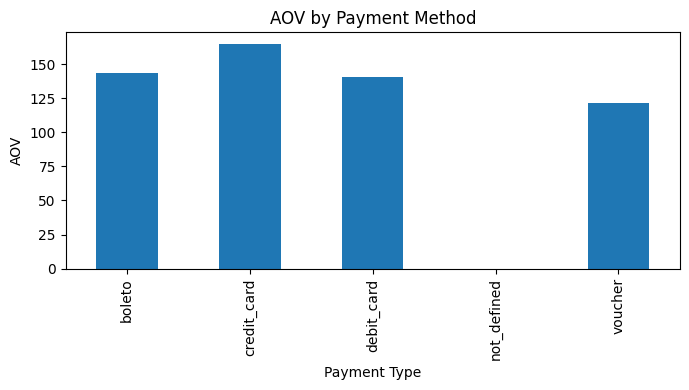

In [ ]:
plt.figure(figsize=(7,4))
AOV_payment.plot(kind='bar')
plt.title("AOV by Payment Method")
plt.xlabel("Payment Type")
plt.ylabel("AOV")
plt.tight_layout()
plt.show()

- Credit card có AOV cao nhất
-> Khách thanh toán bằng credit card có xu hướng chi tiêu nhiều hơn. Có thể  do trả góp không bị giới hạn tiền ngay lập tức
- Voucher có AOV thấp nhất: Khách dùng voucher thường có giá trị đơn hàng thấp hơn.
Có thể đây là kết quả săn deal, mua sản phẩm giá rẻ
- Các phương thức còn lại khá tương đồng: boleto & debit_card ~140–145 ->không chênh lệch nhiều
=> Các phương thức thanh toán truyền thống có mức chi tiêu tương đối ổn định.
==> Giá trị đơn hàng trung bình (AOV) khác nhau đáng kể giữa các phương thức thanh toán.
Cụ thể, khách hàng sử dụng credit card có AOV cao nhất ( khoang 165), cho thấy họ có xu hướng chi tiêu nhiều hơn.
Ngược lại, các đơn hàng sử dụng voucher có AOV thấp nhất ( khoảng 120), phản ánh hành vi săn khuyến mãi hoặc mua các sản phẩm giá thấp.
Các phương thức thanh toán khác như boleto và debit card có mức AOV trung bình và tương đối ổn định.